In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import warnings
warnings.filterwarnings('ignore')

In [90]:
x=np.linspace(-6,6,100)
y=np.sqrt(10**2-x**2) # for each value it caculate 100-x**2...total y values =100
y=np.hstack([y,-y])
x=np.hstack([x,-x])


In [91]:
x.size

200

In [92]:
y.size

200

In [93]:
x1=np.linspace(-6.0,6.0,100)
y1=np.sqrt(4**2-x1**2)
y1=np.hstack([y1,-y1])
x1=np.hstack([x1,-x1])

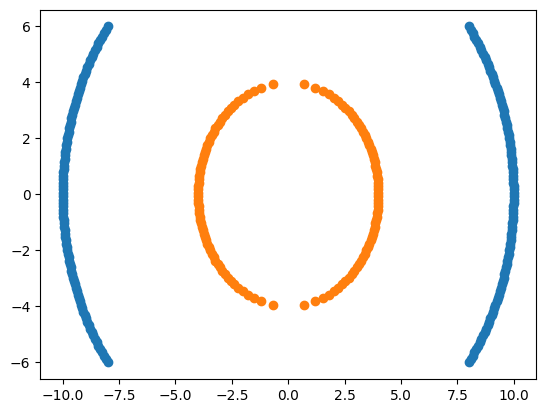

In [94]:
# stacking 
plt.scatter(y,x)
plt.scatter(y1,x1)

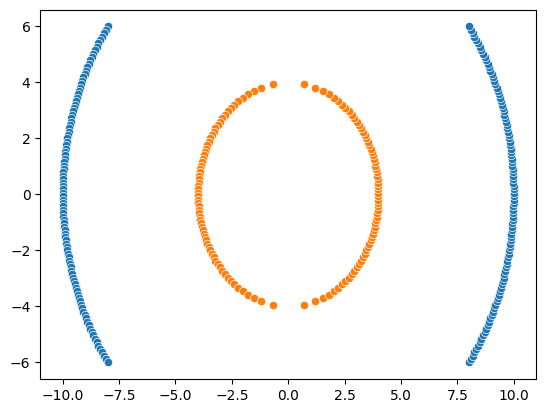

In [95]:
sns.scatterplot(x=y,y=x)
sns.scatterplot(x=y1,y=x1)
plt.show()

In [96]:
df1=pd.DataFrame(np.vstack([y,x]).T,columns=["x1","x2"] )
df1["y"]=0
df1

,x1,x2,y
0,8.000000,-6.000000,0
1,8.089490,-5.878788,0
2,8.176205,-5.757576,0
3,8.260230,-5.636364,0
4,8.341649,-5.515152,0
...,...,...,...
195,-8.341649,-5.515152,0
196,-8.260230,-5.636364,0
197,-8.176205,-5.757576,0
198,-8.089490,-5.878788,0


In [97]:
df2=pd.DataFrame(np.vstack([y1,x1]).T , columns=["x1","x2"])
df2["y"]=1
df3=pd.concat([df1,df2],ignore_index=True)
df3.head()

,x1,x2,y
0,8.000000,-6.000000,0
1,8.089490,-5.878788,0
2,8.176205,-5.757576,0
3,8.260230,-5.636364,0
4,8.341649,-5.515152,0


In [98]:
df=df3.copy()
df

,x1,x2,y
0,8.000000,-6.000000,0
1,8.089490,-5.878788,0
2,8.176205,-5.757576,0
3,8.260230,-5.636364,0
4,8.341649,-5.515152,0
...,...,...,...
395,NaN,-5.515152,1
396,NaN,-5.636364,1
397,NaN,-5.757576,1
398,NaN,-5.878788,1


In [99]:
df.isna().sum()

x1    68
x2     0
y      0
dtype: int64

In [100]:
df["x1square"] = df["x1"]**2
df["x2square"] = df["x2"]**2
df["x1x2"] = df["x1"]*df["x2"]
df.head()
df=df.dropna()

In [101]:
x=df[["x1square","x2square","x1x2"]]
y=df["y"]

In [102]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.3,random_state=1)

In [103]:
import plotly.express as px
!pip install plotly


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [104]:
fig=px.scatter_3d(df,x="x1square",y="x2square",z="x1x2",color="y")
fig.show()

In [105]:
x

,x1square,x2square,x1x2
0,64.000000,36.000000,-48.000000
1,65.439853,34.560147,-47.556397
2,66.850321,33.149679,-47.075117
3,68.231405,31.768595,-46.557662
4,69.583104,30.416896,-46.005457
...,...,...,...
378,4.066116,11.933884,6.965957
379,3.213958,12.786042,6.410445
380,2.332415,13.667585,5.646103
381,1.421488,14.578512,4.552271


In [106]:
y

0      0
1      0
2      0
3      0
4      0
      ..
378    1
379    1
380    1
381    1
382    1
Name: y, Length: 332, dtype: int64

In [107]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,classification_report,accuracy_score
cls=SVC(kernel="linear")
cls.fit(x_train,y_train)
y_pred=cls.predict(x_test)
print(classification_report(y_test,y_pred))
accuracy_score(y_test,y_pred)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        62
           1       1.00      1.00      1.00        38

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



1.0

In [108]:
# we have cretaed 5 dimensions ..but in earlier we have only 2= x1,x2

In [109]:
df3.head()

,x1,x2,y
0,8.000000,-6.000000,0
1,8.089490,-5.878788,0
2,8.176205,-5.757576,0
3,8.260230,-5.636364,0
4,8.341649,-5.515152,0


In [110]:
# poly kernel

x=df[["x1","x2"]]
y=df["y"]
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.3,random_state=1)
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,classification_report,accuracy_score
cls=SVC(kernel="poly")
cls.fit(x_train,y_train)
y_pred=cls.predict(x_test)
print(classification_report(y_test,y_pred))
accuracy_score(y_test,y_pred)

              precision    recall  f1-score   support

           0       0.62      1.00      0.77        62
           1       0.00      0.00      0.00        38

    accuracy                           0.62       100
   macro avg       0.31      0.50      0.38       100
weighted avg       0.38      0.62      0.47       100



0.62

In [ ]:
"""In Support Vector Machine, kernel functions allow the model to learn non-linear decision boundaries by implicitly mapping the input data into a higher-dimensional feature space. Instead of computing the transformation explicitly, the algorithm computes inner products using a kernel function, a technique known as the Kernel Trick.

Different kernels produce different decision boundaries:

Linear kernel: Suitable when data is approximately linearly separable.

Polynomial kernel: Captures polynomial relationships between features.

Radial Basis Function Kernel (RBF): Handles complex nonlinear patterns and is commonly used in practice.

Sigmoid kernel: Behaves similarly to activation functions used in neural networks.

The choice of kernel and its parameters (such as 
𝐶,C, γ, or degree) significantly affects the models performance. Proper tuning allows SVMs to generalize well even for complex datasets. """"

In [ ]:
| Features | Geometry  | Boundary   |
| -------- | --------- | ---------- |
| 1        | line      | point      |
| 2        | plane     | line       |
| 3        | 3D space  | plane      |
| n        | n-D space | hyperplane |
